In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
from google.colab import drive
drive.mount('/content/drive')

import numpy as np, json
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

print("GPU:", tf.config.list_physical_devices('GPU'))   # πρεπει να δειχνει ενα GPU

OUT_DIR     = "/content/drive/MyDrive/Final_RUn/preprocessed_panel"
RESULTS_DIR = "/content/drive/MyDrive/Final_RUn/results"
os.makedirs(RESULTS_DIR, exist_ok=True)
GPU_METRICS = f"{RESULTS_DIR}/gpu_metrics_m9.json"

X_train = np.load(f"{OUT_DIR}/X_train_3d.npy").astype("float32")
X_test  = np.load(f"{OUT_DIR}/X_test_3d.npy").astype("float32")
y_train = np.load(f"{OUT_DIR}/y_train.npy").astype("float32")
y_test  = np.load(f"{OUT_DIR}/y_test.npy").astype("float32")
meta = json.load(open(f"{OUT_DIR}/meta.json"))
T_MIN, T_RANGE = meta["target_min"], meta["target_range"]
yt_kw = y_test * T_RANGE + T_MIN
print("train:", X_train.shape, "test:", X_test.shape)

Mounted at /content/drive
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
train: (48056, 48, 6) test: (12028, 48, 6)


In [2]:
T, F = 48, 6

def build_stacked_lstm():       # Πιν. 3/4, §3.6: 64-32-32, dropout 0.01
    m = models.Sequential([Input((T, F)),
        layers.LSTM(64, return_sequences=True), layers.Dropout(0.01),
        layers.LSTM(32, return_sequences=True), layers.Dropout(0.01),
        layers.LSTM(32), layers.Dropout(0.01),
        layers.Dense(1)])
    m.compile(optimizer="adam", loss="mse"); return m

def build_cnn():                # Πιν. 3: filters=64, kernel=5, pool=2
    m = models.Sequential([Input((T, F)),
        layers.Conv1D(64, 5, padding="same", activation="relu"),
        layers.MaxPooling1D(2), layers.Flatten(), layers.Dense(1)])
    m.compile(optimizer="adam", loss="mse"); return m

def build_cnn_lstm():           # §4: 2 conv, 1 pool, 2 LSTM, 2 dense, 2 dropout
    m = models.Sequential([Input((T, F)),
        layers.Conv1D(64, 5, strides=1, padding="same", activation="relu"),
        layers.Conv1D(32, 3, strides=1, padding="same", activation="relu"),
        layers.MaxPooling1D(2),
        layers.LSTM(128, return_sequences=True), layers.Dropout(0.01),
        layers.LSTM(64), layers.Dropout(0.01),
        layers.Dense(16, activation="relu"), layers.Dense(1)])
    m.compile(optimizer="adam", loss="mse"); return m

def build_bilstm():             # Πιν. 3: units 50, 32
    m = models.Sequential([Input((T, F)),
        layers.Bidirectional(layers.LSTM(50, return_sequences=True)),
        layers.Bidirectional(layers.LSTM(32)),
        layers.Dense(16, activation="relu"), layers.Dense(1)])
    m.compile(optimizer="adam", loss="mse"); return m

BUILDERS = {"Stacked LSTM": build_stacked_lstm, "1D-CNN": build_cnn,
            "CNN-LSTM": build_cnn_lstm, "Bi-LSTM": build_bilstm}

In [3]:
from tensorflow.keras import callbacks

RUNS, MAX_EPOCHS, BATCH = 5, 100, 200
SEEDS = [42, 43, 44, 45, 46]

def evaluate_dl(name, builder):
    rmses, maes, r2s, preds, stops = [], [], [], [], []
    for r in range(RUNS):
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(SEEDS[r])
        es = callbacks.EarlyStopping(monitor="val_loss", patience=12,
                                     restore_best_weights=True)
        model = builder()
        h = model.fit(X_train, y_train, epochs=MAX_EPOCHS, batch_size=BATCH,
                      validation_split=0.1, verbose=0, callbacks=[es])
        stops.append(int(np.argmin(h.history["val_loss"])) + 1)   # καλυτερη epoch
        p_kw = model.predict(X_test, verbose=0).ravel() * T_RANGE + T_MIN
        rmses.append(root_mean_squared_error(yt_kw, p_kw))
        maes.append(mean_absolute_error(yt_kw, p_kw))
        r2s.append(r2_score(yt_kw, p_kw))
        preds.append(p_kw)
        print(f"  {name} run {r+1}/{RUNS}: best_epoch={stops[-1]:3d}  "
              f"RMSE={rmses[-1]:.4f}  R2={r2s[-1]:.4f}")
    res = {"RMSE": float(np.mean(rmses)), "RMSE_std": float(np.std(rmses)),
           "MAE":  float(np.mean(maes)),  "MAE_std":  float(np.std(maes)),
           "R2":   float(np.mean(r2s)),   "R2_std":   float(np.std(r2s)),
           "best_epoch_mean": float(np.mean(stops))}
    rec = json.load(open(GPU_METRICS)) if os.path.exists(GPU_METRICS) else {}
    rec[name] = res
    json.dump(rec, open(GPU_METRICS, "w"), indent=2)
    np.save(f"{RESULTS_DIR}/pred_{name}.npy", preds[int(np.argmin(rmses))])
    print(f"{name}: RMSE {res['RMSE']:.4f} ± {res['RMSE_std']:.4f} | "
          f"MAE {res['MAE']:.4f} ± {res['MAE_std']:.4f} | "
          f"R2 {res['R2']:.4f} ± {res['R2_std']:.4f} | best_epoch≈{res['best_epoch_mean']:.0f}\n")

for name, builder in BUILDERS.items():
    print(f"=== {name} ===")
    evaluate_dl(name, builder)

=== Stacked LSTM ===
  Stacked LSTM run 1/5: best_epoch= 13  RMSE=2.6373  R2=0.8612
  Stacked LSTM run 2/5: best_epoch= 13  RMSE=2.6263  R2=0.8624
  Stacked LSTM run 3/5: best_epoch= 15  RMSE=2.7522  R2=0.8489
  Stacked LSTM run 4/5: best_epoch= 11  RMSE=2.6964  R2=0.8549
  Stacked LSTM run 5/5: best_epoch= 18  RMSE=2.6975  R2=0.8548
Stacked LSTM: RMSE 2.6820 ± 0.0458 | MAE 1.7678 ± 0.0740 | R2 0.8565 ± 0.0049 | best_epoch≈14

=== 1D-CNN ===
  1D-CNN run 1/5: best_epoch= 19  RMSE=2.6405  R2=0.8609
  1D-CNN run 2/5: best_epoch= 21  RMSE=2.6477  R2=0.8601
  1D-CNN run 3/5: best_epoch= 28  RMSE=2.7488  R2=0.8493
  1D-CNN run 4/5: best_epoch= 31  RMSE=2.6771  R2=0.8570
  1D-CNN run 5/5: best_epoch= 32  RMSE=2.7267  R2=0.8517
1D-CNN: RMSE 2.6881 ± 0.0429 | MAE 1.7690 ± 0.0387 | R2 0.8558 ± 0.0046 | best_epoch≈26

=== CNN-LSTM ===
  CNN-LSTM run 1/5: best_epoch= 15  RMSE=2.6125  R2=0.8638
  CNN-LSTM run 2/5: best_epoch= 12  RMSE=2.6348  R2=0.8615
  CNN-LSTM run 3/5: best_epoch= 11  RMSE=2.70

In [4]:
import pandas as pd
rec = json.load(open(GPU_METRICS))
rows = [{"Model": k,
         "RMSE": f"{v['RMSE']:.4f} ± {v['RMSE_std']:.4f}",
         "MAE":  f"{v['MAE']:.4f} ± {v['MAE_std']:.4f}",
         "R2":   f"{v['R2']:.4f} ± {v['R2_std']:.4f}"} for k, v in rec.items()]
print(pd.DataFrame(rows).to_string(index=False))

       Model            RMSE             MAE              R2
Stacked LSTM 2.6820 ± 0.0458 1.7678 ± 0.0740 0.8565 ± 0.0049
      1D-CNN 2.6881 ± 0.0429 1.7690 ± 0.0387 0.8558 ± 0.0046
    CNN-LSTM 2.6306 ± 0.0443 1.6849 ± 0.0816 0.8619 ± 0.0047
     Bi-LSTM 2.6528 ± 0.0384 1.7329 ± 0.0258 0.8596 ± 0.0040


In [5]:
import matplotlib.pyplot as plt

FIG_DIR = "/content/drive/MyDrive/Final_RUn/figures"
os.makedirs(FIG_DIR, exist_ok=True)

meta = json.load(open(f"{OUT_DIR}/meta.json"))
yt_kw = y_test * meta["target_range"] + meta["target_min"]

metrics = {}
for p in [f"{RESULTS_DIR}/cpu_metrics_m9.json", f"{RESULTS_DIR}/gpu_metrics_m9.json"]:
    if os.path.exists(p):
        metrics.update(json.load(open(p)))

DISPLAY = {"RandomForest": "Random Forest"}
COLORS = {"XGBoost": "#2a7fb8", "RandomForest": "#b8336a", "SVR": "#16a085",
          "Stacked LSTM": "#e67e22", "1D-CNN": "#8e44ad",
          "CNN-LSTM": "#27ae60", "Bi-LSTM": "#c0392b"}
load_pred = lambda nm: np.load(f"{RESULTS_DIR}/pred_{nm}.npy")

def panel_figure(model_names, title, fname, n_points=500):
    disp = [DISPLAY.get(m, m) for m in model_names]
    rmse = [metrics[m]["RMSE"] for m in model_names]
    mae  = [metrics[m]["MAE"]  for m in model_names]
    r2   = [metrics[m]["R2"]   for m in model_names]
    cols = [COLORS.get(m, "#555") for m in model_names]
    fig, ax = plt.subplots(2, 2, figsize=(15, 10)); x = np.arange(len(model_names)); w = 0.38

    b1 = ax[0,0].bar(x-w/2, mae, w, label="MAE", color="#2a7fb8")
    b2 = ax[0,0].bar(x+w/2, rmse, w, label="RMSE", color="#b8336a")
    ax[0,0].set_title("Σύγκριση MAE & RMSE"); ax[0,0].set_ylabel("Error (kW)")
    ax[0,0].set_xticks(x); ax[0,0].set_xticklabels(disp, rotation=15); ax[0,0].legend()
    for b in list(b1)+list(b2):
        ax[0,0].text(b.get_x()+b.get_width()/2, b.get_height(), f"{b.get_height():.3f}",
                     ha="center", va="bottom", fontsize=9)

    b3 = ax[0,1].bar(x, r2, color=cols)
    ax[0,1].set_title("Σύγκριση R² Score"); ax[0,1].set_ylabel("R²")
    ax[0,1].set_ylim(min(r2)-0.05, 1.0); ax[0,1].set_xticks(x); ax[0,1].set_xticklabels(disp, rotation=15)
    for b in b3:
        ax[0,1].text(b.get_x()+b.get_width()/2, b.get_height(), f"{b.get_height():.4f}",
                     ha="center", va="bottom", fontsize=9, fontweight="bold")

    ax[1,0].plot(yt_kw[:n_points], color="black", lw=1.3, label="Actual")
    for m, d in zip(model_names, disp):
        ax[1,0].plot(load_pred(m)[:n_points], lw=0.9, alpha=0.8, color=COLORS.get(m, "#555"), label=d)
    ax[1,0].set_title(f"Πραγματικές vs Προβλεπόμενες (πρώτες {n_points} test)")
    ax[1,0].set_xlabel("Time Steps (5 min)"); ax[1,0].set_ylabel("Active Power (kW)"); ax[1,0].legend(fontsize=8)

    for m, d in zip(model_names, disp):
        ax[1,1].scatter(yt_kw, load_pred(m), s=4, alpha=0.25, color=COLORS.get(m, "#555"), label=d)
    lim = [min(yt_kw.min(), 0), yt_kw.max()]
    ax[1,1].plot(lim, lim, "r--", lw=1.2, label="Perfect Prediction")
    ax[1,1].set_title("Predicted vs Actual"); ax[1,1].set_xlabel("Actual (kW)")
    ax[1,1].set_ylabel("Predicted (kW)"); ax[1,1].legend(fontsize=8, markerscale=2)

    fig.suptitle(title, fontsize=14, fontweight="bold"); fig.tight_layout(rect=[0,0,1,0.97])
    fig.savefig(f"{FIG_DIR}/{fname}", dpi=150, bbox_inches="tight"); plt.show()

def comparison_figure(model_names, title, fname):
    paper = {"XGBoost": (2.9185,1.2988,0.8511), "SVR": (2.9245,1.2918,0.8501),
             "1D-CNN": (2.9388,1.3105,0.8498), "CNN-LSTM": (3.0810,1.3876,0.7909),
             "Bi-LSTM": (2.9125,1.3032,0.8301), "Stacked LSTM": (2.7681,1.2453,0.8711)}
    order = [m for m in model_names if m in metrics]
    disp = [DISPLAY.get(m, m) for m in order]; x = np.arange(len(order)); w = 0.38
    fig, ax = plt.subplots(1, 3, figsize=(16, 5))
    for j,(key,idx,lbl) in enumerate([("RMSE",0,"RMSE (kW)"),("MAE",1,"MAE (kW)"),("R2",2,"R²")]):
        mine = [metrics[m][key] for m in order]
        ax[j].bar(x-w/2, mine, w, label="Δικά μου (M9)", color="#2a7fb8")
        pidx = [i for i, m in enumerate(order) if m in paper]      # μονο οσα εχουν αντιστοιχο
        if pidx:
            py = [paper[order[i]][idx] for i in pidx]
            ax[j].bar(np.array(pidx)+w/2, py, w, label="Singh et al. (1B)", color="#b8336a")
        ax[j].set_title(lbl); ax[j].set_xticks(x); ax[j].set_xticklabels(disp, rotation=20); ax[j].legend()
        if key == "R2": ax[j].set_ylim(0.75, 0.9)
    fig.suptitle(title, fontsize=14, fontweight="bold"); fig.tight_layout(rect=[0,0,1,0.95])
    fig.savefig(f"{FIG_DIR}/{fname}", dpi=150, bbox_inches="tight"); plt.show()

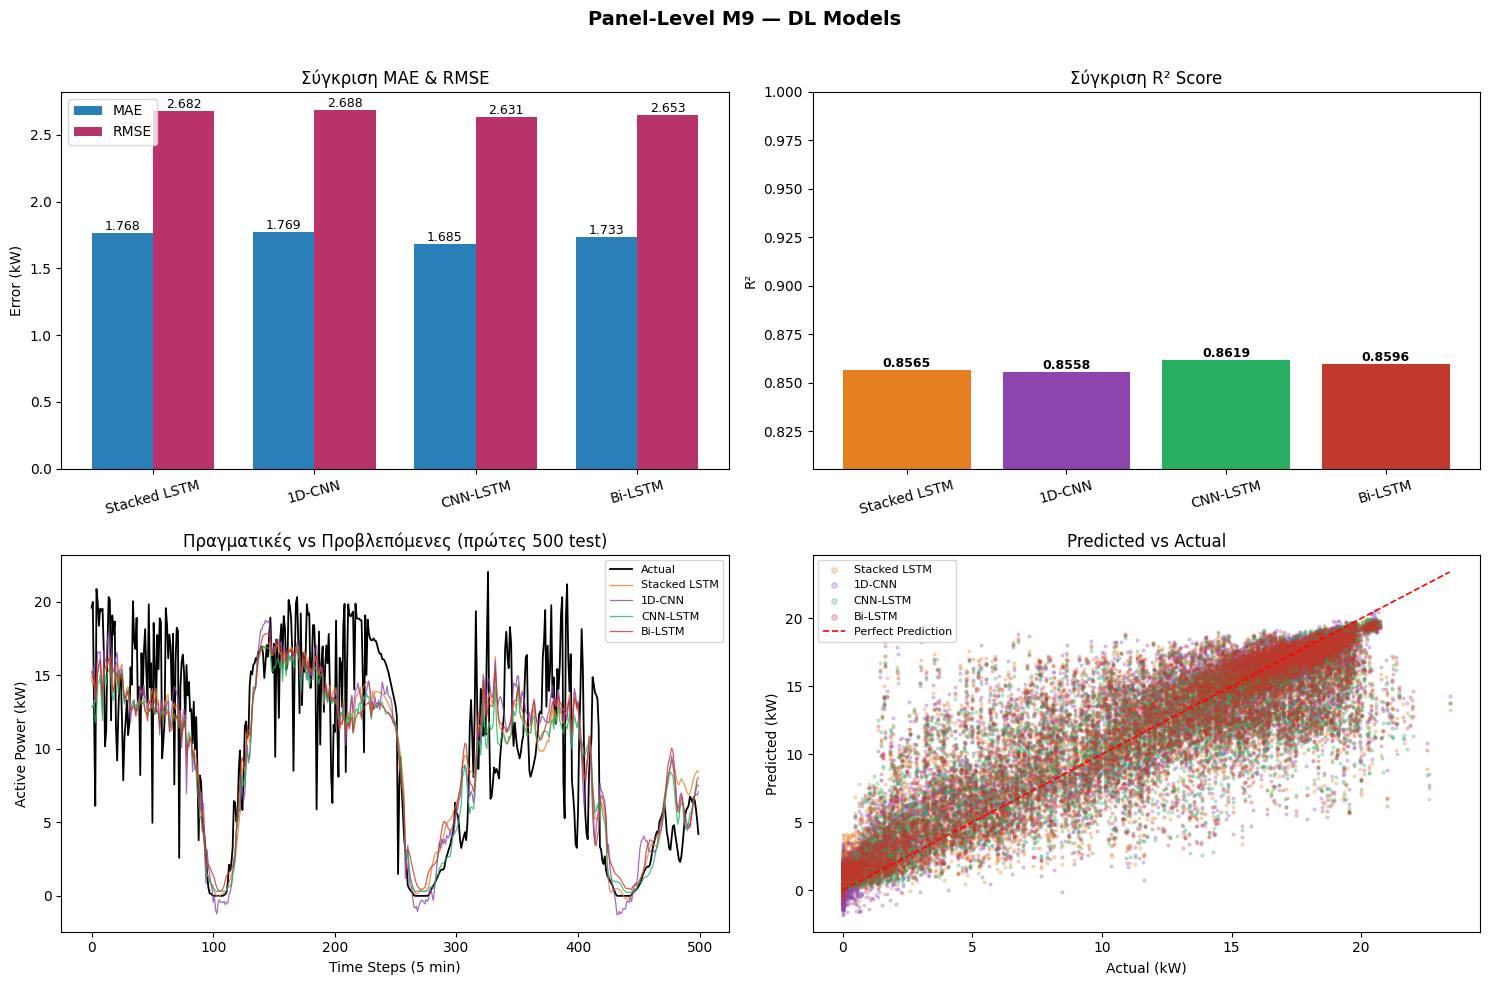

In [6]:
panel_figure(["Stacked LSTM", "1D-CNN", "CNN-LSTM", "Bi-LSTM"], "Panel-Level M9 — DL Models", "panel_m9_gpu.png")

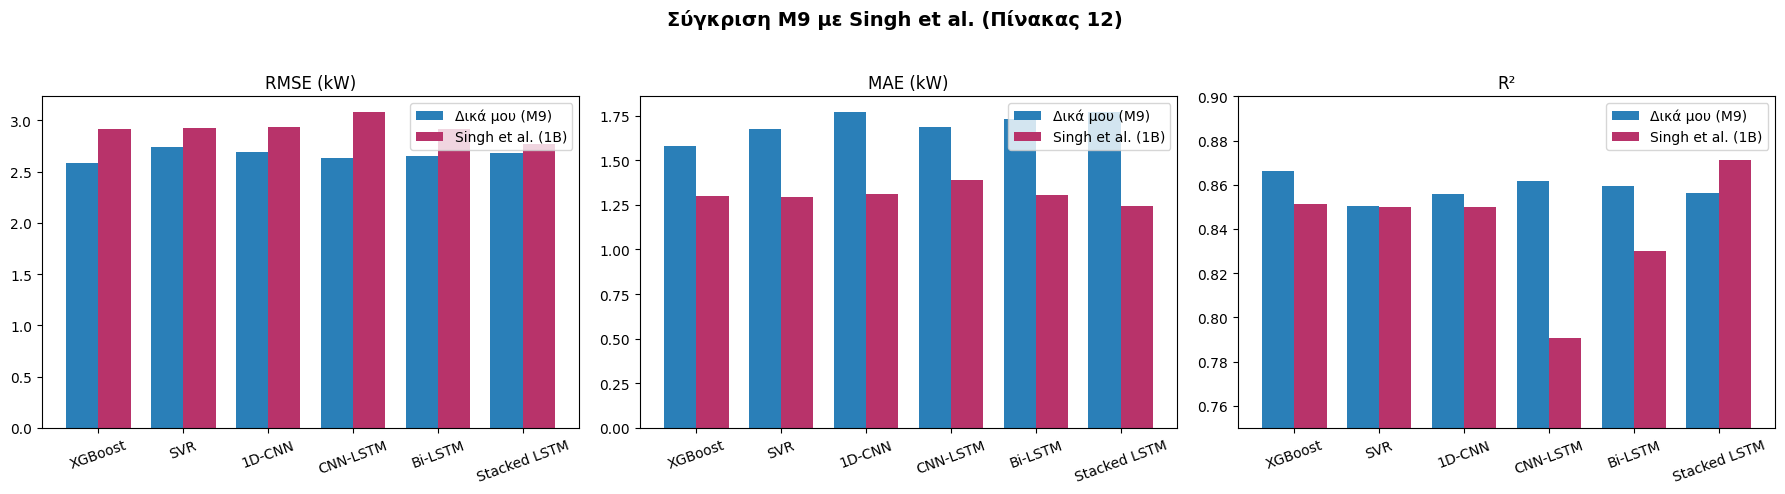

In [7]:
comparison_figure()

In [11]:
def comparison_figure(model_names, title, fname):
    paper = {"XGBoost": (2.9185,1.2988,0.8511), "SVR": (2.9245,1.2918,0.8501),
             "1D-CNN": (2.9388,1.3105,0.8498), "CNN-LSTM": (3.0810,1.3876,0.7909),
             "Bi-LSTM": (2.9125,1.3032,0.8301), "Stacked LSTM": (2.7681,1.2453,0.8711)}
    order = [m for m in model_names if m in metrics]
    disp = [DISPLAY.get(m, m) for m in order]; x = np.arange(len(order)); w = 0.38
    fig, ax = plt.subplots(1, 3, figsize=(16, 5))
    for j,(key,idx,lbl) in enumerate([("RMSE",0,"RMSE (kW)"),("MAE",1,"MAE (kW)"),("R2",2,"R²")]):
        mine = [metrics[m][key] for m in order]
        ax[j].bar(x-w/2, mine, w, label="Δικά μου (M9)", color="#2a7fb8")
        pidx = [i for i, m in enumerate(order) if m in paper]
        if pidx:
            py = [paper[order[i]][idx] for i in pidx]
            ax[j].bar(np.array(pidx)+w/2, py, w, label="Singh et al. (1B)", color="#b8336a")
        ax[j].set_title(lbl); ax[j].set_xticks(x); ax[j].set_xticklabels(disp, rotation=20); ax[j].legend()
        if key == "R2": ax[j].set_ylim(0.75, 0.9)
    fig.suptitle(title, fontsize=14, fontweight="bold"); fig.tight_layout(rect=[0,0,1,0.95])
    fig.savefig(f"{FIG_DIR}/{fname}", dpi=150, bbox_inches="tight"); plt.show()

import inspect
print(inspect.signature(comparison_figure))

(model_names, title, fname)


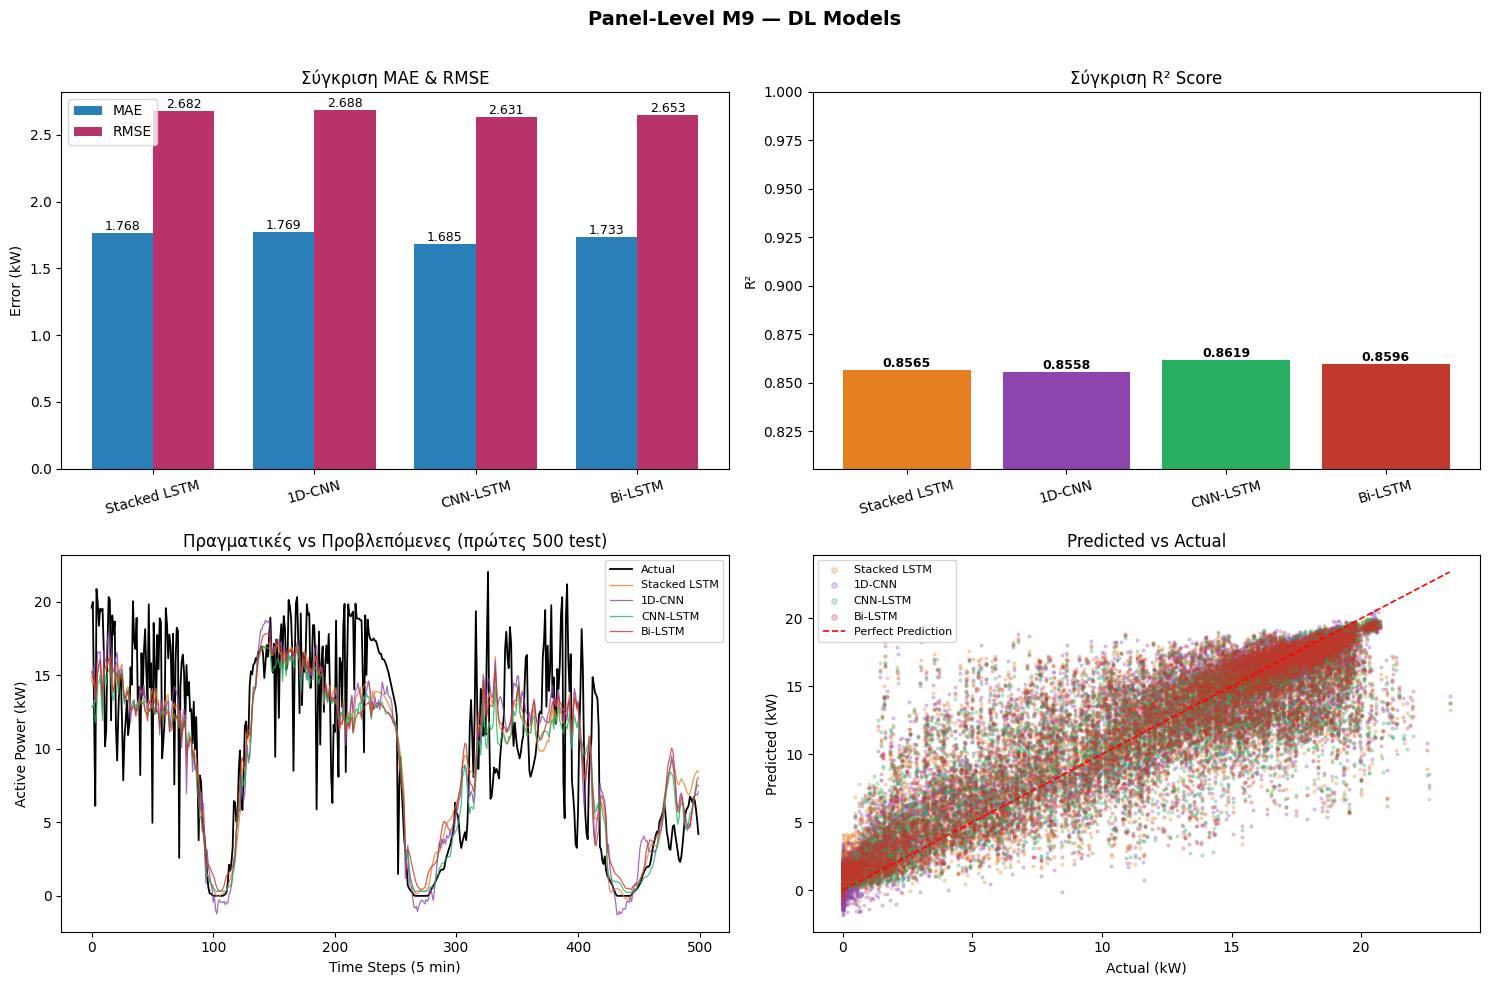

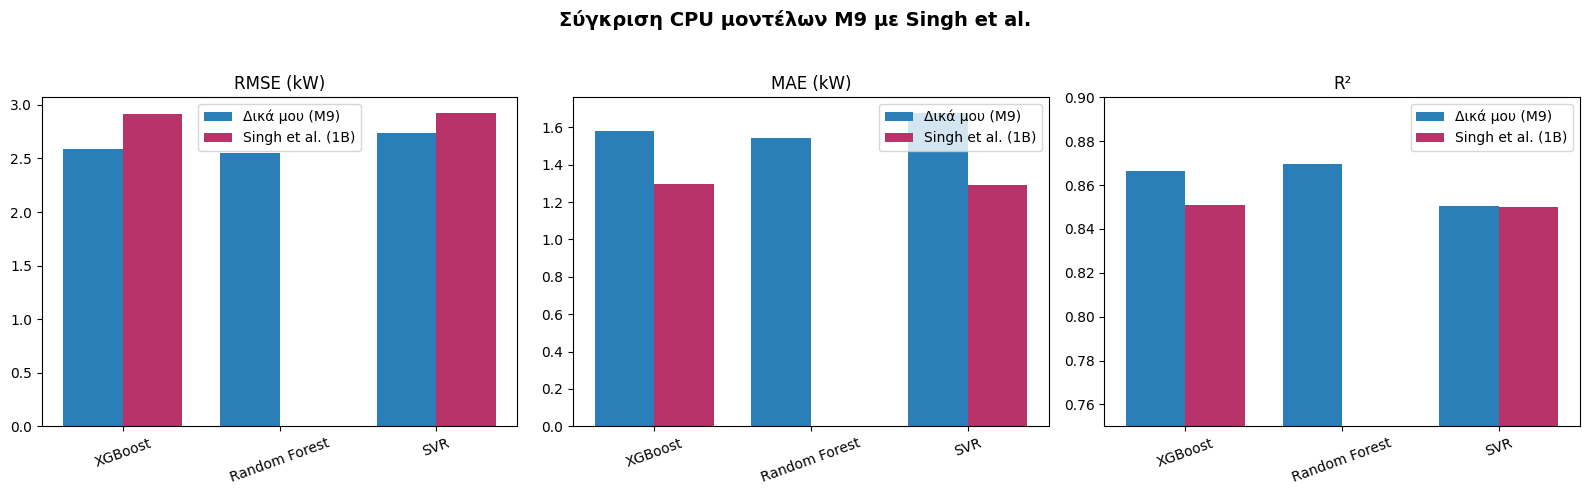

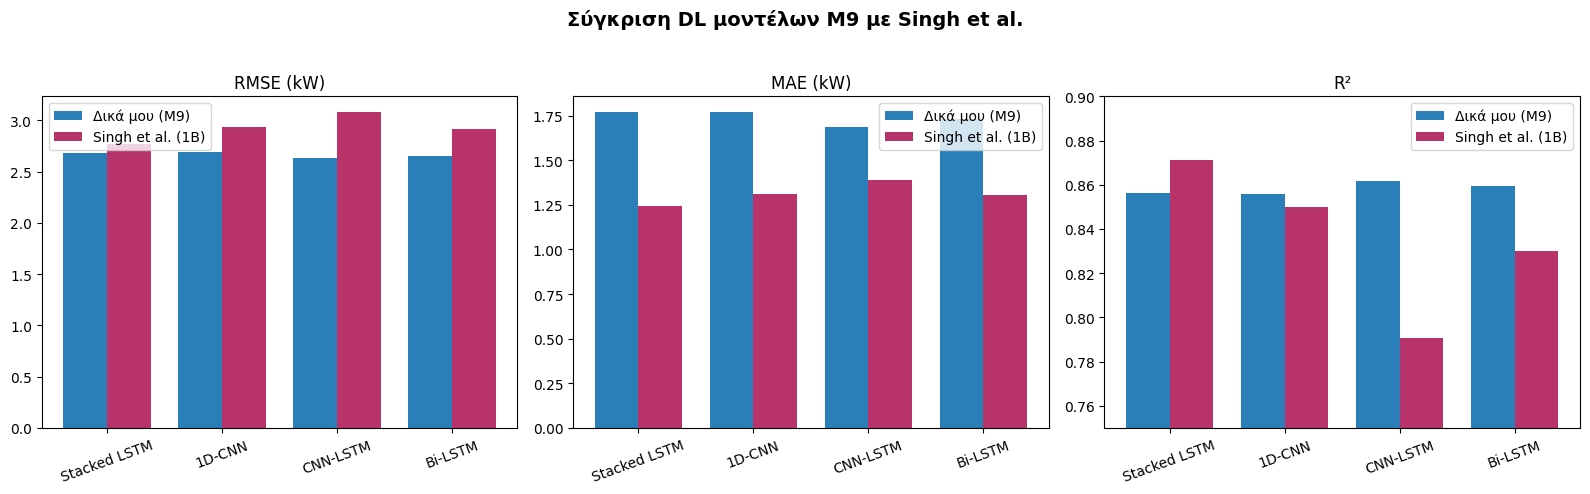

In [12]:
metrics = {}
for p in [f"{RESULTS_DIR}/cpu_metrics_m9.json", f"{RESULTS_DIR}/gpu_metrics_m9.json"]:
    if os.path.exists(p):
        metrics.update(json.load(open(p)))

panel_figure(["Stacked LSTM", "1D-CNN", "CNN-LSTM", "Bi-LSTM"],
             "Panel-Level M9 — DL Models", "panel_m9_gpu.png")

comparison_figure(["XGBoost", "RandomForest", "SVR"],
                  "Σύγκριση CPU μοντέλων M9 με Singh et al.", "panel_m9_cpu_vs_paper.png")
comparison_figure(["Stacked LSTM", "1D-CNN", "CNN-LSTM", "Bi-LSTM"],
                  "Σύγκριση DL μοντέλων M9 με Singh et al.", "panel_m9_gpu_vs_paper.png")